<a href="https://colab.research.google.com/github/Vivekshrotriya1/7-March/blob/main/Capstone_Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Capstone Project 4
Project Scenario
Smart Traffic Sign Recognition System Scenario A city is building a Smart Traffic Monitoring System to improve road safety.

Every intersection in the city will have cameras that detect traffic signs automatically.

The system must recognize different road signs such as:

Stop sign

Speed limit sign

Pedestrian crossing sign

The system will be used in autonomous vehicles and traffic monitoring cameras.

However, the engineers discovered two challenges:

First, the system must understand basic classification logic (learning from features).
Second, it must classify images of traffic signs captured by cameras.
To solve this, the engineering team decided to build the system in two stages.

Stage 1
Learning Basic Neural Networks (Perceptron) Before building a full image model, the engineers want students to first implement a Perceptron-based neural network to understand how neural networks make decisions.

The perceptron will predict whether a traffic sign means "STOP" or "NOT STOP" using extracted features.

CAPSTONE PROJECT 4
Traffic Sign Perceptron


Saving DatasetCapstoneProject4.csv to DatasetCapstoneProject4 (1).csv

Dataset Head:
   Sign_ID  Red_Color_Intensity  Circular_Shape  Text_Present  Edge_Count  \
0        1                 0.90               0             1           8   
1        2                 0.20               1             0           4   
2        3                 0.85               0             1           7   
3        4                 0.30               1             0           5   
4        5                 0.88               0             1           8   

   Stop_Sign  
0          1  
1          0  
2          1  
3          0  
4          1  


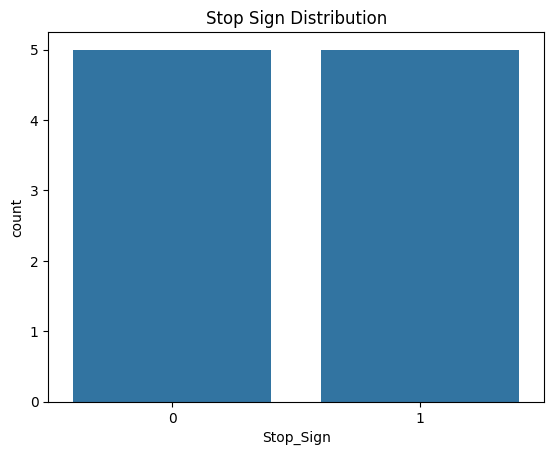

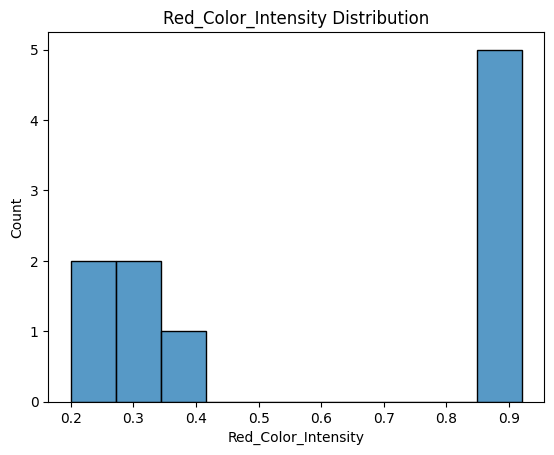

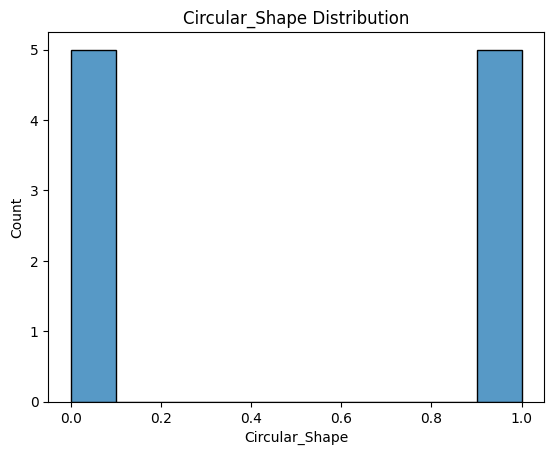

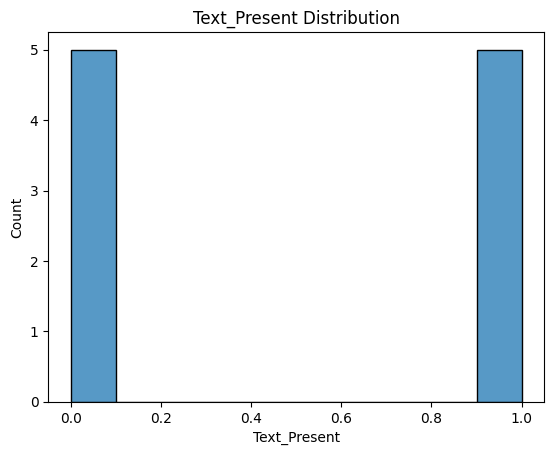

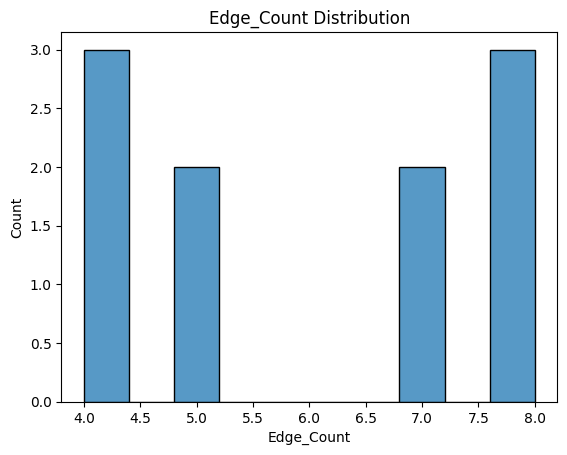

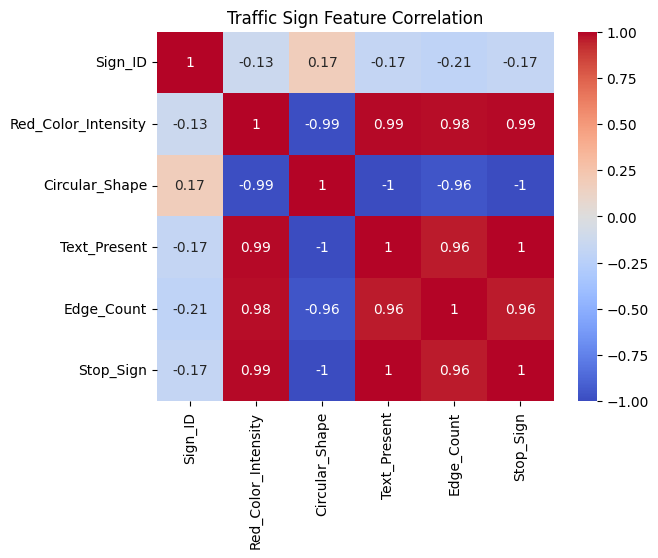


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



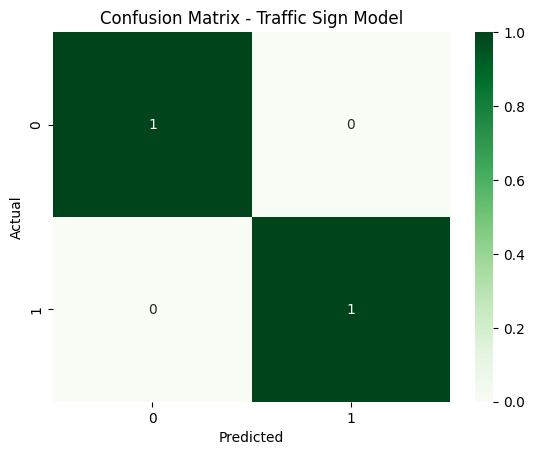


Detected: NOT STOP SIGN

All Capstone Projects Completed Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


In [5]:
# CAPSTONE PROJECT 4
# Traffic Sign Recognition
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import Perceptron


print("CAPSTONE PROJECT 4")
print("Traffic Sign Perceptron")

from google.colab import files
uploaded = files.upload()
df2 = pd.read_csv("DatasetCapstoneProject4.csv")

print("\nDataset Head:")
print(df2.head())


# DATA VISUALIZATION


# Stop Sign Distribution
plt.figure()
sns.countplot(x="Stop_Sign", data=df2)
plt.title("Stop Sign Distribution")
plt.show()

# Feature Distributions
features = ["Red_Color_Intensity", "Circular_Shape", "Text_Present", "Edge_Count"]

for f in features:
    plt.figure()
    sns.histplot(df2[f], bins=10)
    plt.title(f + " Distribution")
    plt.show()

# Correlation Heatmap
plt.figure()
sns.heatmap(df2.corr(), annot=True, cmap="coolwarm")
plt.title("Traffic Sign Feature Correlation")
plt.show()


# MODEL TRAINING


X2 = df2.drop(["Sign_ID", "Stop_Sign"], axis=1)
y2 = df2["Stop_Sign"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

perceptron = Perceptron(max_iter=1000, eta0=0.1)

perceptron.fit(X_train2, y_train2)

y_pred2 = perceptron.predict(X_test2)

print("\nAccuracy:", accuracy_score(y_test2, y_pred2))

print("\nClassification Report:")
print(classification_report(y_test2, y_pred2))

# Confusion Matrix Visualization
plt.figure()
sns.heatmap(confusion_matrix(y_test2, y_pred2), annot=True, cmap="Greens")
plt.title("Confusion Matrix - Traffic Sign Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Sample Prediction


new_sign = np.array([[0.9, 1, 1, 8]])

prediction = perceptron.predict(new_sign)

if prediction == 1:
    print("\nDetected: STOP SIGN")
else:
    print("\nDetected: NOT STOP SIGN")

print("\nAll Capstone Projects Completed Successfully")